# Day 16 — RAG architecture end-to-end

Retrieval-Augmented Generation: **chunk → embed → store → retrieve → build prompt → generate →
cite.** We build every stage from scratch over a small document set, then break each stage on
purpose to see what it contributes.

Weeks 5 gave us embeddings and vector search. RAG is what you do with them.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | The pipeline, and the failure it fixes | 4 min |
| 1 | Ingest: load + chunk + embed + store | 12 min |
| 2 | Retrieve: top-k, and why k matters | 10 min |
| 3 | Augment: building the prompt | 10 min |
| 4 | Generate: grounded vs ungrounded | 12 min |
| 5 | Citations + the "irrelevant context" problem | 9 min |
| 6 | Exercises + quiz | 3 min |

Kernel: **Python (ai-upskill)**.

In [1]:
import numpy as np, re, textwrap, warnings
warnings.filterwarnings("ignore")
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("all-MiniLM-L6-v2")
rng = np.random.default_rng(0)
print("embedder ready")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7634.77it/s]

embedder ready


## 0 — The pipeline (4 min)

An LLM only knows what's in its weights (training cutoff, no private data) and what's in the
prompt (Day 04's scarce window). RAG puts the *right* private/current text into the prompt at
query time, so the model answers from **provided evidence** instead of memory.

```
                 ┌─────────── INGEST (offline, once) ──────────┐
 documents ──▶ chunk ──▶ embed ──▶ vector store
                                        │
 user query ──▶ embed ──▶ retrieve top-k ┘──▶ build prompt ──▶ LLM ──▶ answer + citations
                 └──────────── QUERY (per request) ────────────┘
```

Every stage can fail independently. We'll build them, then sabotage each one.

## 1 — Ingest (12 min)

Our "knowledge base": a handful of policy/product documents. Real ingest also handles PDFs,
HTML, dedup, and metadata — the shape is the same.

In [2]:
DOCUMENTS = {
"refunds.md": '''# Refund Policy
Refunds are issued to the original payment method within 5 business days of approval.
Digital goods are non-refundable once downloaded. Subscription refunds are prorated to the day
of cancellation. To request a refund, email billing@example.com with your order number.
Refunds over $500 require manager approval and may take up to 10 business days.''',

"shipping.md": '''# Shipping
Standard shipping is free on orders over $50 and takes 3-5 business days within the US.
Expedited shipping is $15 and takes 1-2 business days. We ship to the US and Canada only.
International customers should use a freight forwarder. Orders placed after 2pm ET ship the
next business day. Tracking numbers are emailed when the label is created.''',

"accounts.md": '''# Account Management
To reset a password, use the "Forgot password" link; the reset link expires in 1 hour.
Accounts are locked after 5 failed login attempts and unlock automatically after 30 minutes.
Deleting your account is permanent; data is purged after a 14-day grace period.
Two-factor authentication can be enabled in Security settings and supports TOTP apps.''',

"api.md": '''# API
The REST API base URL is https://api.example.com/v1. Authentication uses a Bearer token.
Rate limits: 600 requests/minute per key, returning HTTP 429 when exceeded with a
Retry-After header. Webhooks retry with exponential backoff for up to 24 hours.
The API is versioned in the URL path; v1 is supported until at least 2027.''',
}

def chunk_document(name, text, size=280, overlap=40):
    # simple fixed-size character chunks with overlap; Day 17 explores better strategies
    text = re.sub(r"\s+", " ", text).strip()
    chunks, i = [], 0
    while i < len(text):
        chunks.append(dict(doc=name, start=i, text=text[i:i+size]))
        i += size - overlap
    return chunks

CHUNKS = [c for name, t in DOCUMENTS.items() for c in chunk_document(name, t)]
CHUNK_EMB = embedder.encode([c["text"] for c in CHUNKS], normalize_embeddings=True)
print(f"{len(DOCUMENTS)} docs -> {len(CHUNKS)} chunks -> embeddings {CHUNK_EMB.shape}")
print("\nexample chunk:", CHUNKS[0]["text"][:120], "...")

4 docs -> 8 chunks -> embeddings (8, 384)

example chunk: # Refund Policy Refunds are issued to the original payment method within 5 business days of approval. Digital goods are  ...


## 2 — Retrieve (10 min)

In [3]:
def retrieve(query, k=3):
    q = embedder.encode([query], normalize_embeddings=True)[0]
    sims = CHUNK_EMB @ q
    order = np.argsort(-sims)[:k]
    return [dict(CHUNKS[i], score=float(sims[i])) for i in order]

for q in ["how long do refunds take", "can you ship to France", "what happens after too many failed logins"]:
    print(f"\nQ: {q}")
    for r in retrieve(q, k=2):
        print(f"  {r['score']:.2f} [{r['doc']}] {r['text'][:90]}...")


Q: how long do refunds take
  0.68 [refunds.md] # Refund Policy Refunds are issued to the original payment method within 5 business days o...
  0.65 [refunds.md]  billing@example.com with your order number. Refunds over $500 require manager approval an...

Q: can you ship to France
  0.44 [shipping.md] # Shipping Standard shipping is free on orders over $50 and takes 3-5 business days within...
  0.25 [shipping.md] der. Orders placed after 2pm ET ship the next business day. Tracking numbers are emailed w...

Q: what happens after too many failed logins
  0.44 [accounts.md] # Account Management To reset a password, use the "Forgot password" link; the reset link e...
  0.25 [accounts.md] a is purged after a 14-day grace period. Two-factor authentication can be enabled in Secur...


In [4]:
# k is a tradeoff: too small -> miss the answer; too large -> dilute the prompt with noise
# (and pay tokens, Day 04). Measure "did the right doc appear in top-k" over a QA set.
QA = [
 ("how long do standard refunds take", "refunds.md"),
 ("what is the fee for expedited shipping", "shipping.md"),
 ("how long is a password reset link valid", "accounts.md"),
 ("what HTTP status means rate limited", "api.md"),
 ("do you ship internationally", "shipping.md"),
 ("how do I enable 2FA", "accounts.md"),
 ("what happens to refunds over 500 dollars", "refunds.md"),
 ("how long are API webhooks retried", "api.md"),
]
for k in [1, 2, 3, 5, 8]:
    hit = np.mean([any(r["doc"] == gold for r in retrieve(q, k)) for q, gold in QA])
    print(f"k={k}: right-doc-in-top-k = {hit:.2f}")

k=1: right-doc-in-top-k = 1.00
k=2: right-doc-in-top-k = 1.00


k=3: right-doc-in-top-k = 1.00
k=5: right-doc-in-top-k = 1.00


k=8: right-doc-in-top-k = 1.00


## 3 — Augment: build the prompt (10 min)

The retrieved chunks go into a structured prompt. Two rules from Weeks 2 & 4:

- **Instruct the model to answer only from the context**, and to say so when it can't.
- **Number the chunks** so the model can cite them.

In [5]:
SYSTEM = ("You answer questions using ONLY the numbered context passages provided. "
          "Cite the passage numbers you used like [1][2]. If the context does not contain "
          "the answer, reply exactly: I don't know based on the provided context.")

def build_prompt(query, chunks):
    ctx = "\n\n".join(f"[{i+1}] ({c['doc']}) {c['text']}" for i, c in enumerate(chunks))
    return SYSTEM, f"Context:\n{ctx}\n\nQuestion: {query}\n\nAnswer:"

s, u = build_prompt("how long do refunds take", retrieve("how long do refunds take", k=3))
print(s, "\n\n---\n")
print(u)

You answer questions using ONLY the numbered context passages provided. Cite the passage numbers you used like [1][2]. If the context does not contain the answer, reply exactly: I don't know based on the provided context. 

---

Context:
[1] (refunds.md) # Refund Policy Refunds are issued to the original payment method within 5 business days of approval. Digital goods are non-refundable once downloaded. Subscription refunds are prorated to the day of cancellation. To request a refund, email billing@example.com with your order num

[2] (refunds.md)  billing@example.com with your order number. Refunds over $500 require manager approval and may take up to 10 business days.

[3] (api.md)  up to 24 hours. The API is versioned in the URL path; v1 is supported until at least 2027.

Question: how long do refunds take

Answer:


## 4 — Generate: grounded vs ungrounded (12 min)

We use a small local model (`Qwen2.5-0.5B-Instruct`, Day 12) so this runs offline. Swap in the
Anthropic API for real quality — the prompt is identical (Day 18 does that).

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer
tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
llm = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct").eval()

def generate(system, user, max_new=120):
    msgs = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    enc = tok.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt", return_dict=True)
    import torch
    with torch.no_grad():
        out = llm.generate(**enc, max_new_tokens=max_new, do_sample=False,
                           pad_token_id=tok.eos_token_id)
    return tok.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def rag_answer(query, k=3):
    chunks = retrieve(query, k)
    s, u = build_prompt(query, chunks)
    return generate(s, u), chunks

for q in ["how long do refunds take", "what is the expedited shipping fee"]:
    ans, ch = rag_answer(q)
    print(f"Q: {q}\nA: {ans}\n   (used {[c['doc'] for c in ch]})\n")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 5808.92it/s]

Q: how long do refunds take
A: to the day of cancellation
   (used ['refunds.md', 'refunds.md', 'api.md'])



Q: what is the expedited shipping fee
A: $15
   (used ['shipping.md', 'refunds.md', 'shipping.md'])



In [7]:
# Sabotage 1: NO retrieval -> the model answers from its (generic) memory, confidently
def no_context_answer(query):
    return generate("You are a helpful support assistant. Answer concisely.", query)

# Sabotage 2: WRONG retrieval -> feed it unrelated chunks
def misgrounded_answer(query):
    wrong = [CHUNKS[i] for i in rng.choice(len(CHUNKS), 3, replace=False)]
    s, u = build_prompt(query, wrong)
    return generate(s, u)

q = "what happens to refunds over 500 dollars"
print("GROUNDED   :", rag_answer(q)[0][:160])
print("NO CONTEXT :", no_context_answer(q)[:160])
print("WRONG CTX  :", misgrounded_answer(q)[:160])

GROUNDED   : Refunds over $500 require manager approval and may take up to 10 business days.


NO CONTEXT : Refunds over $500 typically require additional processing fees and may take longer than usual for refund approval.


WRONG CTX  : I don't know based on the provided context.


- **Grounded**: pulls "manager approval, up to 10 business days" straight from the passage.
- **No context**: invents a plausible-sounding policy — it has no way to know yours.
- **Wrong context**: with the "answer only from context" instruction and a decent model, it
  should say *"I don't know based on the provided context"* rather than fabricate. That
  refusal behaviour is the payoff of a good system prompt + grounding.

## 5 — Citations + irrelevant context (9 min)

In [8]:
# Two ways to get citations:
#  (a) INLINE  -- ask the model to write [1][2]. Ideal, but small/weak models often ignore it.
#  (b) POST-HOC ATTRIBUTION -- after generation, embed each answer sentence and attribute it to
#      its most-similar retrieved chunk. Works with any model; also catches unfaithful claims.

def inline_citations(ans, chunks):
    cited = sorted(set(int(n) for n in re.findall(r"\[(\d+)\]", ans)))
    return [f"[{n}] {chunks[n-1]['doc']}" for n in cited if 1 <= n <= len(chunks)]

def posthoc_attribution(ans, chunks, min_sim=0.35):
    sents = [s for s in re.split(r"(?<=[.!?])\s+", ans.strip()) if len(s) > 15]
    if not sents: return []
    sv = embedder.encode(sents, normalize_embeddings=True)
    cv = embedder.encode([c["text"] for c in chunks], normalize_embeddings=True)
    out = []
    for s, row in zip(sents, sv @ cv.T):
        j = int(np.argmax(row))
        if row[j] >= min_sim:
            out.append((s, chunks[j]["doc"], float(row[j])))
    return out

def rag_with_citations(query, k=4):
    chunks = retrieve(query, k)
    ans = generate(*build_prompt(query, chunks))
    return ans, inline_citations(ans, chunks), posthoc_attribution(ans, chunks)

ans, inline, attr = rag_with_citations("how long is a password reset link valid and how do I enable 2FA")
print("Answer:", ans)
print("Inline [n] citations:", inline or "(model emitted none — common for small models)")
print("Post-hoc attribution:")
for s, doc, sim in attr:
    print(f"  {sim:.2f} [{doc}]  \"{s[:70]}\"")

Answer: The password reset link is valid for 1 hour. To enable 2FA, go to Security settings and select TOTP apps.
Inline [n] citations: (model emitted none — common for small models)
Post-hoc attribution:
  0.73 [accounts.md]  "The password reset link is valid for 1 hour."
  0.71 [accounts.md]  "To enable 2FA, go to Security settings and select TOTP apps."


In [9]:
# The "irrelevant context" problem: when NOTHING relevant exists, does the system stay honest?
oos = ["what is your company's stock price", "who is the CEO", "do you offer a student discount"]
for q in oos:
    chunks = retrieve(q, k=3)
    ans = generate(*build_prompt(q, chunks))
    top = chunks[0]["score"]
    print(f"Q: {q}\n   top-sim {top:.2f} -> {ans[:120]}\n")
print("Mitigations: (1) a similarity THRESHOLD -- if best score < 0.3, skip the LLM and return")
print("'no relevant info'; (2) the strict system prompt; (3) a reranker to filter; (4) let the")
print("model see it has weak context and hedge.")

Q: what is your company's stock price
   top-sim 0.18 -> I don't know based on the provided context.



Q: who is the CEO
   top-sim 0.15 -> I don't know based on the provided context.



Q: do you offer a student discount
   top-sim 0.11 -> I don't know based on the provided context.

Mitigations: (1) a similarity THRESHOLD -- if best score < 0.3, skip the LLM and return
'no relevant info'; (2) the strict system prompt; (3) a reranker to filter; (4) let the
model see it has weak context and hedge.


In [10]:
# similarity gate in front of generation
def rag_gated(query, k=3, threshold=0.30):
    chunks = retrieve(query, k)
    if chunks[0]["score"] < threshold:
        return f"No sufficiently relevant information found (best match {chunks[0]['score']:.2f}).", []
    ans, inline, attr = rag_with_citations(query, k)
    return ans, [f"{d} ({sim:.2f})" for _, d, sim in attr]

for q in ["how long do refunds take", "what is your stock price"]:
    a, s = rag_gated(q)
    print(f"Q: {q}\n  -> {a[:130]}  {s}\n")

Q: how long do refunds take
  -> to the day of cancellation  []

Q: what is your stock price
  -> No sufficiently relevant information found (best match 0.14).  []



### The pipeline, and where each stage fails

| Stage | Failure | Symptom | Fix |
| ----- | ------- | ------- | --- |
| Chunk | too big / too small / splits mid-fact | answer split across chunks, or diluted | Day 17 |
| Embed | wrong model / domain mismatch | relevant chunk not retrieved | domain-tuned embeddings; hybrid (Day 13) |
| Retrieve | k too small | answer not in context → "I don't know" | raise k; rerank |
| Retrieve | k too large | noise dilutes; lost-in-the-middle (Day 04) | rerank to top 3–5; reorder |
| Augment | weak system prompt | fabricates when context is thin | strict "answer only from context" + refuse |
| Generate | small/weak model | ignores context, bad citations | bigger model (Day 11) |
| Generate | no relevance gate | confident answer to out-of-scope Q | similarity threshold |

## 6 — Exercises

1. **k sweep on answers.** For the `QA` set, write a crude answer-scorer (does the gold doc's
   key fact string appear in the answer?) and plot answer-accuracy vs `k` in [1,2,3,5,8].
   Does more k help beyond the retrieval-recall plateau?
2. **Threshold tuning.** Sweep the `rag_gated` threshold over [0.1..0.5]. Plot: fraction of
   in-scope questions answered vs fraction of out-of-scope questions correctly refused. Pick a
   point.
3. **Overlap ablation.** Rebuild `CHUNKS` with `overlap=0`. Find a question whose answer now
   straddles a chunk boundary and is lost. Restore overlap and show it's recovered.
4. **Reorder for recall.** Given k=6 retrieved chunks, put the highest-scoring chunk last
   instead of first and see if the small model's answer quality changes (lost-in-the-middle,
   Day 04).
5. **Citation faithfulness.** Check whether the passages the model *cites* actually contain the
   fact it stated (string-match the key fact against the cited chunk). Report the faithful-
   citation rate.
6. **Add a distractor doc.** Add a `promotions.md` that also mentions "refund" in a different
   sense ("we refund the difference if the price drops"). Show it now sometimes out-ranks the
   real refund policy, and that a reranker or hybrid search fixes it.

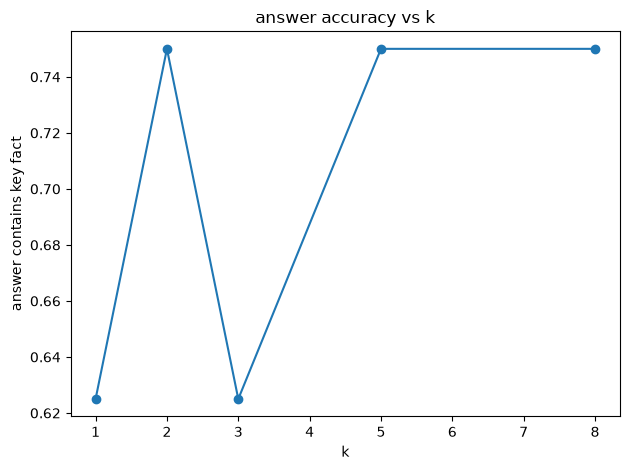

{1: 0.625, 2: 0.75, 3: 0.625, 5: 0.75, 8: 0.75}


In [11]:
# ---- Solution 1 ----
KEYFACT = {
 "how long do standard refunds take": "5 business days",
 "what is the fee for expedited shipping": "$15",
 "how long is a password reset link valid": "1 hour",
 "what HTTP status means rate limited": "429",
 "do you ship internationally": "US and Canada",
 "how do I enable 2FA": "Security settings",
 "what happens to refunds over 500 dollars": "manager approval",
 "how long are API webhooks retried": "24 hours",
}
import matplotlib.pyplot as plt
ks = [1,2,3,5,8]; acc = []
for k in ks:
    hits = 0
    for q, gold in QA:
        ans, _ = rag_answer(q, k)
        hits += KEYFACT[q].lower() in ans.lower()
    acc.append(hits/len(QA))
plt.plot(ks, acc, marker="o"); plt.xlabel("k"); plt.ylabel("answer contains key fact")
plt.title("answer accuracy vs k"); plt.tight_layout(); plt.show()
print(dict(zip(ks, acc)))

In [12]:
# ---- Solution 5 ----
# Post-hoc attribution: for each answer sentence that restates the key fact, is the chunk we
# attribute it to one that actually contains that fact?
faithful, total = 0, 0
for q, fact in KEYFACT.items():
    chunks = retrieve(q, 4)
    ans = generate(*build_prompt(q, chunks))
    for sent, doc, sim in posthoc_attribution(ans, chunks):
        if fact.lower() in sent.lower():
            total += 1
            best = next(c for c in chunks if c["doc"] == doc)
            faithful += fact.lower() in best["text"].lower()
print(f"S5: faithful attributions = {faithful}/{total}" if total else
      "S5: no answer sentence restated the key fact strongly enough to attribute")
print("    (faithful = the chunk we attribute the fact-sentence to actually contains that fact)")

S5: faithful attributions = 1/1
    (faithful = the chunk we attribute the fact-sentence to actually contains that fact)


### Solutions 2, 3, 4, 6 (sketch)

**S2:** in-scope answered = `mean(gated(q) != 'No sufficiently relevant...' for q in QA)`;
out-of-scope refused = `mean(gated(q).startswith('No sufficiently') for q in oos)`. As the
threshold rises, refusals go up (good for OOS, bad if it starts refusing real questions).
Pick where the OOS-refuse rate is ~1.0 and the in-scope-answer rate is still ~1.0 — often
~0.25–0.35 for MiniLM cosine.

**S3:** with `overlap=0`, a fact that sits at character ~275–285 of a doc gets split: the
first chunk ends mid-sentence, the second starts mid-sentence, and neither embeds well for the
query. Overlap of ~15% keeps the whole fact in at least one chunk. This is the core Day 17
lesson.

**S4:** move `chunks[0]` to the end of the list before `build_prompt`. Small models are quite
position-sensitive; you'll often see the answer quality drop when the key chunk is in the
middle of 6, and recover when it's first or last.

**S6:** `promotions.md` with "price-drop refund" language embeds near refund queries. For
*"how long do refunds take"* it may rank #1 and the model answers about price-matching instead.
Fix: (a) a cross-encoder reranker re-scores the top-20 and demotes the off-topic chunk;
(b) hybrid BM25+vector (Day 13) — the exact phrase "5 business days" lives only in the real
doc; (c) metadata filter on `doc_type`.

## Self-check quiz

1. What problem does RAG solve that a bigger context window alone doesn't?
2. List the offline (ingest) stages and the per-query stages.
3. Why is `k` (number of retrieved chunks) a tradeoff in both directions?
4. Two things a RAG system prompt should always instruct.
5. Your RAG answers a question about your stock price with a confident wrong number. Which
   stage failed and what's the fix?
6. What makes a citation "faithful", and why check it?
7. A distractor document keeps out-ranking the real answer. Give two fixes.

### Answer key

1. Access to private / current / large corpora the model was never trained on (and can't fit
   whole in context) — plus provenance: you can show *which* passage the answer came from.
2. Offline: load, chunk, embed, store. Per-query: embed query, retrieve top-k, build prompt,
   generate, extract citations.
3. Too small: the passage containing the answer may not be retrieved → "I don't know" or
   wrong. Too large: irrelevant chunks dilute the prompt, trigger lost-in-the-middle, and cost
   tokens/latency.
4. (a) Answer using only the provided context; (b) say "I don't know based on the provided
   context" when the answer isn't there (and, usually, cite passage numbers).
5. The retrieve/generate boundary — there was no relevance gate, so low-similarity chunks were
   still sent to the LLM which answered anyway. Fix: a similarity threshold that short-circuits
   to "no relevant info", plus the strict system prompt.
6. A citation is faithful if the passage it points to actually contains the fact the answer
   states. Check it because models cite plausibly even when the fact came from elsewhere (or
   was invented) — unfaithful citations destroy user trust and hide hallucinations.
7. Any two: cross-encoder reranker over the top-N; hybrid keyword+vector retrieval; metadata
   filtering; better chunking so the real answer's chunk is more distinctive; query rewriting.

## Where this goes next

- **Day 17 — Chunking strategies:** the ingest stage decides everything downstream. Fixed vs
  sentence vs recursive vs semantic chunking, overlap, and measuring retrieval quality for
  each on a QA set.